# Preventive Care Gap Prediction: Model Development and Evaluation

This notebook develops and evaluates three selected models for predicting preventive care gaps:

1. **Logistic Regression** — baseline and interpretable benchmark
2. **Random Forest** — ensemble tree-based model
3. **XGBoost** — gradient-boosting model

A **Decision Tree** is retained as an exploratory model but is not included in the main three-model results.


In [1]:
#!pip install xgboost

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

candidate_paths = [
    Path("result(1).csv"),
    Path("result.csv"),
    Path("../outputs/result.csv"),
    Path("outputs/result.csv"),
    Path(r"C:\Users\GH\Downloads\result(1).csv"),
    Path(r"C:\Users\GH\Downloads\result.csv")
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not locate result(1).csv or result.csv. "
        "Place the CSV in the same folder as this notebook or update candidate_paths."
    )

print("Data path:", DATA_PATH.resolve())


Data path: C:\Users\chang\Downloads\result.csv


## 1. Data Preparation


In [3]:
df = pd.read_csv(DATA_PATH)

PREDICTORS = [
    "r_caregiver", "r_insurance", "r_persdoc", "r_cost_barrier",
    "r_genhlth", "r_menthlth", "r_diabetes", "r_michd",
    "r_diffwalk", "r_decide", "r_diffalon", "r_smoker", "r_active",
    "r_female", "r_ageband", "r_race", "r_educ", "r_income", "r_employ"
]

CATEGORICAL_FEATURES = [
    "r_insurance", "r_smoker", "r_race", "r_income", "r_employ"
]
NUMERIC_FEATURES = [
    column for column in PREDICTORS
    if column not in CATEGORICAL_FEATURES
]

required_columns = PREDICTORS + ["r_no_checkup"]
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

assert df.shape[0] == 86676, f"Expected 86,676 rows, found {df.shape[0]:,}"
assert df[required_columns].isna().sum().sum() == 0

print("Dataset shape:", df.shape)
print("Outcome event rate:", round(df["r_no_checkup"].mean(), 4))


Dataset shape: (86676, 24)
Outcome event rate: 0.1818


In [4]:
X = df[PREDICTORS].copy()
y = df["r_no_checkup"].astype(int)

for column in CATEGORICAL_FEATURES:
    X[column] = X[column].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=True
            ),
            CATEGORICAL_FEATURES
        ),
        ("num", "passthrough", NUMERIC_FEATURES)
    ],
    verbose_feature_names_out=False
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
FEATURE_NAMES = preprocessor.get_feature_names_out()

print("Training rows:", len(y_train))
print("Testing rows:", len(y_test))
print("Encoded features:", X_train_encoded.shape[1])
print("Training event rate:", round(y_train.mean(), 4))
print("Testing event rate:", round(y_test.mean(), 4))


Training rows: 60673
Testing rows: 26003
Encoded features: 38
Training event rate: 0.1818
Testing event rate: 0.1817


In [5]:
def evaluate_binary_model(name, model, X_eval, y_eval, threshold=0.50):
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, predictions).ravel()

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Sensitivity": tp / (tp + fn),
        "Specificity": tn / (tn + fp),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "F1": f1_score(y_eval, predictions),
        "AUROC": roc_auc_score(y_eval, probabilities),
        "AUPRC": average_precision_score(y_eval, probabilities),
        "Brier": brier_score_loss(y_eval, probabilities),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }
    return metrics, probabilities, predictions


## 2. Model Development


### 2.1 Logistic Regression — Baseline Model

Logistic Regression is used as the baseline model because it provides an interpretable benchmark through coefficients and odds ratios.


In [6]:
logistic_regression = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE
)

logistic_regression.fit(X_train_encoded, y_train)

lr_metrics, lr_probabilities, lr_predictions = evaluate_binary_model(
    "Logistic Regression",
    logistic_regression,
    X_test_encoded,
    y_test
)

pd.DataFrame([lr_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Logistic Regression,0.771,0.678,0.791,0.419,0.518,0.814,0.541,0.168,16840,4437,1524,3202


### 2.2 Decision Tree

Decision Tree is used to capture non-linear relationships and interactions between predictors while providing an interpretable set of decision rules.


In [7]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train_encoded, y_train)

dt_metrics, dt_probabilities, dt_predictions = evaluate_binary_model(
    "Decision Tree",
    decision_tree,
    X_test_encoded,
    y_test
)

pd.DataFrame([dt_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Decision Tree,0.782,0.639,0.814,0.432,0.516,0.798,0.491,0.172,17314,3963,1706,3020


### 2.3 Random Forest

Random Forest is used to capture non-linear relationships and interactions across multiple decision trees.


In [8]:
random_forest = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest.fit(X_train_encoded, y_train)

rf_metrics, rf_probabilities, rf_predictions = evaluate_binary_model(
    "Random Forest",
    random_forest,
    X_test_encoded,
    y_test
)

pd.DataFrame([rf_metrics]).round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,Random Forest,0.77,0.677,0.791,0.418,0.517,0.813,0.555,0.165,16829,4448,1528,3198


### 2.4 XGBoost

XGBoost is used as a boosting-based model capable of capturing complex non-linear relationships.


In [9]:
scale_pos_weight = float(
    (y_train == 0).sum() / (y_train == 1).sum()
)
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgboost_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgboost_model.fit(X_train_encoded, y_train)

xgb_metrics, xgb_probabilities, xgb_predictions = evaluate_binary_model(
    "XGBoost",
    xgboost_model,
    X_test_encoded,
    y_test
)

pd.DataFrame([xgb_metrics]).round(3)


scale_pos_weight: 4.502


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier,TN,FP,FN,TP
0,XGBoost,0.768,0.685,0.787,0.416,0.518,0.816,0.561,0.166,16740,4537,1491,3235


## 3. Model Evaluation — Selected Models

Although the Decision Tree achieved the highest accuracy (0.782) and specificity (0.814), it had the lowest sensitivity (0.639), AUROC (0.798), and AUPRC (0.491). As identifying individuals with preventive care gaps was of greater interest than overall classification accuracy alone, the primary analysis focused on Logistic Regression, Random Forest, and XGBoost. The Decision Tree was retained as an exploratory model.

The primary project results focus on Logistic Regression, Random Forest and XGBoost.  
Decision Tree results are retained separately as exploratory analysis.


In [22]:
selected_model_results = pd.DataFrame([
    lr_metrics,
    rf_metrics,
    xgb_metrics,
    dt_metrics
])

selected_model_results.to_csv(
    RESULTS / "selected_model_results.csv",
    index=False
)

selected_model_results[
    [
        "Model", "Accuracy", "Sensitivity", "Specificity",
        "Precision", "F1", "AUROC", "AUPRC", "Brier"
    ]
].round(3)


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier
0,Logistic Regression,0.771,0.678,0.791,0.419,0.518,0.814,0.541,0.168
1,Random Forest,0.770,0.677,0.791,0.418,0.517,0.813,0.555,0.165
2,XGBoost,0.768,0.685,0.787,0.416,0.518,0.816,0.561,0.166
3,Decision Tree,0.782,0.639,0.814,0.432,0.516,0.798,0.491,0.172


### 3.1 ROC Curves


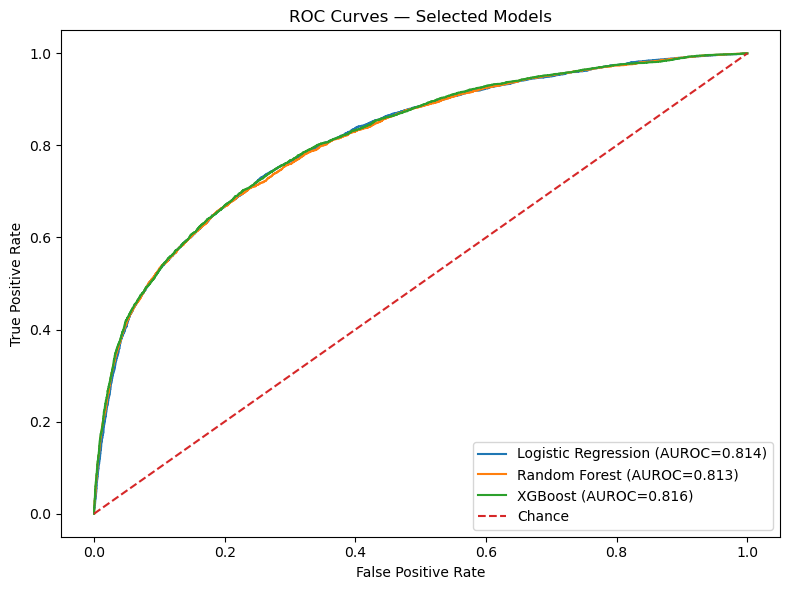

In [11]:
selected_model_probabilities = {
    "Logistic Regression": (lr_probabilities, lr_metrics),
    "Random Forest": (rf_probabilities, rf_metrics),
    "XGBoost": (xgb_probabilities, xgb_metrics)
}

plt.figure(figsize=(8, 6))

for model_name, (probabilities, metrics) in selected_model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUROC={metrics['AUROC']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Selected Models")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "selected_model_roc_curves.png", dpi=200)
plt.show()


### 3.2 Precision–Recall Curves


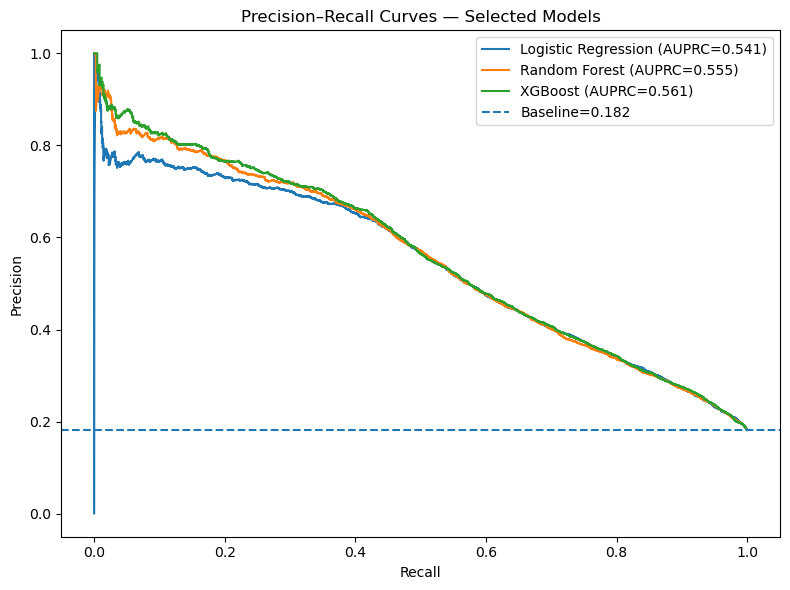

In [12]:
plt.figure(figsize=(8, 6))

for model_name, (probabilities, metrics) in selected_model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUPRC={metrics['AUPRC']:.3f})"
    )

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Selected Models")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "selected_model_precision_recall_curves.png", dpi=200)
plt.show()


### 3.3 Confusion Matrices


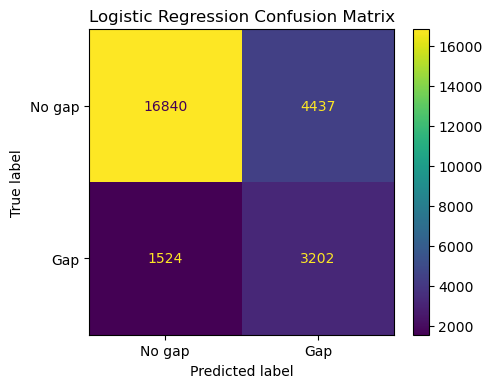

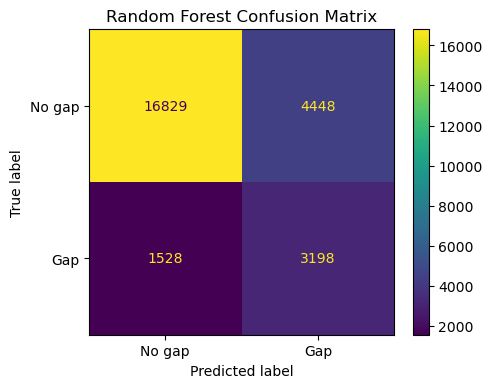

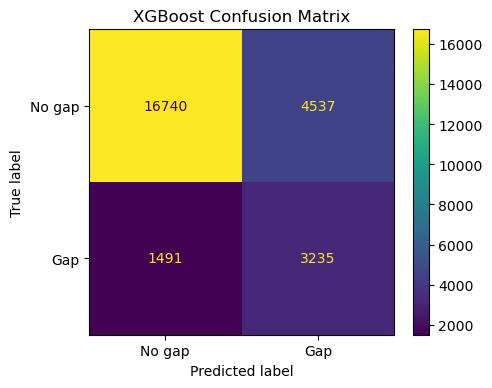

In [13]:
selected_model_predictions = {
    "Logistic Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
}

for model_name, predictions in selected_model_predictions.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No gap", "Gap"],
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    fig.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    fig.savefig(
        RESULTS / f"{safe_name}_confusion_matrix.png",
        dpi=200
    )
    plt.show()


### Evaluation Note

Because `r_no_checkup = 1` is less common than `r_no_checkup = 0`, accuracy should not be interpreted alone.

- **Sensitivity** measures how many respondents with a preventive care gap are correctly identified.
- **Specificity** measures how many respondents without a care gap are correctly identified.
- **AUROC** measures overall class discrimination.
- **AUPRC** is particularly useful for evaluating performance on the less common positive class.
- **Brier score** evaluates the accuracy of predicted probabilities; lower values are better.

All three selected models use the same predictors, preprocessing, stratified train-test split and held-out test set.


## 4. Model Interpretation


### 4.1 Logistic Regression — Coefficients and Odds Ratios

Positive coefficients / odds ratios above 1 are associated with higher odds of a preventive care gap.  
Negative coefficients / odds ratios below 1 are associated with lower odds of a preventive care gap, relative to the corresponding reference category or coding.


In [14]:
lr_results = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Coefficient": logistic_regression.coef_[0]
})

lr_results["Odds_Ratio"] = np.exp(lr_results["Coefficient"])
lr_results["Abs_Coefficient"] = lr_results["Coefficient"].abs()

lr_results = lr_results.sort_values(
    "Abs_Coefficient",
    ascending=False
)

lr_results.to_csv(
    RESULTS / "logistic_regression_odds_ratios.csv",
    index=False
)

print("Top Logistic Regression Predictors")
display(
    lr_results[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].head(15).round(3)
)


Top Logistic Regression Predictors


,Feature,Coefficient,Odds_Ratio
25,r_persdoc,-1.947,0.143
29,r_diabetes,-0.993,0.371
6,r_insurance_uninsured,0.613,1.847
26,r_cost_barrier,0.565,1.760
2,r_insurance_military_ihs,-0.544,0.580
9,r_race_2.0,-0.539,0.583
22,r_employ_unable,-0.497,0.608
21,r_employ_retired,-0.431,0.650
7,r_smoker_former,-0.348,0.706
30,r_michd,-0.319,0.727


In [15]:
positive_lr = (
    lr_results[lr_results["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

negative_lr = (
    lr_results[lr_results["Coefficient"] < 0]
    .sort_values("Coefficient")
    .head(10)
)

print("Predictors associated with HIGHER likelihood of a preventive care gap:")
display(
    positive_lr[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].round(3)
)

print("\nPredictors associated with LOWER likelihood of a preventive care gap:")
display(
    negative_lr[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].round(3)
)


Predictors associated with HIGHER likelihood of a preventive care gap:


,Feature,Coefficient,Odds_Ratio
6,r_insurance_uninsured,0.613,1.847
26,r_cost_barrier,0.565,1.760
33,r_diffalon,0.181,1.198
3,r_insurance_not_reported,0.059,1.061
14,r_income_band_3,0.045,1.046
13,r_income_band_2,0.036,1.037
15,r_income_band_4,0.024,1.024
5,r_insurance_private,0.018,1.018
28,r_menthlth,0.005,1.005



Predictors associated with LOWER likelihood of a preventive care gap:


,Feature,Coefficient,Odds_Ratio
25,r_persdoc,-1.947,0.143
29,r_diabetes,-0.993,0.371
2,r_insurance_military_ihs,-0.544,0.580
9,r_race_2.0,-0.539,0.583
22,r_employ_unable,-0.497,0.608
21,r_employ_retired,-0.431,0.650
7,r_smoker_former,-0.348,0.706
30,r_michd,-0.319,0.727
35,r_female,-0.312,0.732
8,r_smoker_never,-0.304,0.738


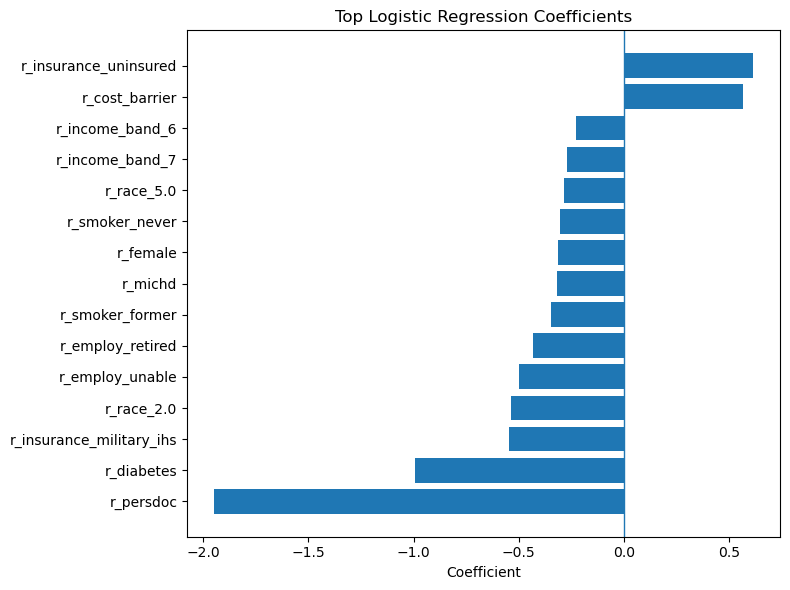

In [16]:
lr_top = lr_results.head(15).sort_values("Coefficient")

plt.figure(figsize=(8, 6))
plt.barh(lr_top["Feature"], lr_top["Coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(
    RESULTS / "logistic_regression_coefficients.png",
    dpi=200
)
plt.show()


### 4.2 Random Forest — Feature Importance


Top Random Forest Predictors


,Feature,Importance
25,r_persdoc,0.3693
36,r_ageband,0.1590
21,r_employ_retired,0.0877
29,r_diabetes,0.0624
6,r_insurance_uninsured,0.0580
1,r_insurance_medicare,0.0505
26,r_cost_barrier,0.0325
35,r_female,0.0217
31,r_diffwalk,0.0175
27,r_genhlth,0.0169


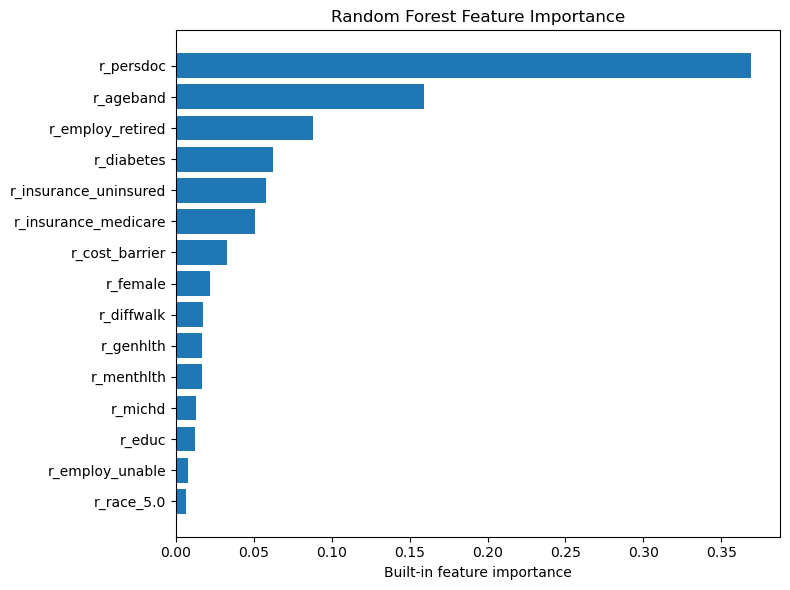

In [17]:
rf_results = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": random_forest.feature_importances_
}).sort_values("Importance", ascending=False)

rf_results.to_csv(
    RESULTS / "random_forest_feature_importance.csv",
    index=False
)

print("Top Random Forest Predictors")
display(rf_results.head(15).round(4))

rf_top = rf_results.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(rf_top["Feature"], rf_top["Importance"])
plt.xlabel("Built-in feature importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(
    RESULTS / "random_forest_feature_importance.png",
    dpi=200
)
plt.show()


### 4.3 XGBoost — Feature Importance


Top XGBoost Predictors


,Feature,Importance
25,r_persdoc,0.6034
21,r_employ_retired,0.0524
36,r_ageband,0.0447
29,r_diabetes,0.0445
6,r_insurance_uninsured,0.0440
26,r_cost_barrier,0.0247
35,r_female,0.0153
1,r_insurance_medicare,0.0133
31,r_diffwalk,0.0126
22,r_employ_unable,0.0115


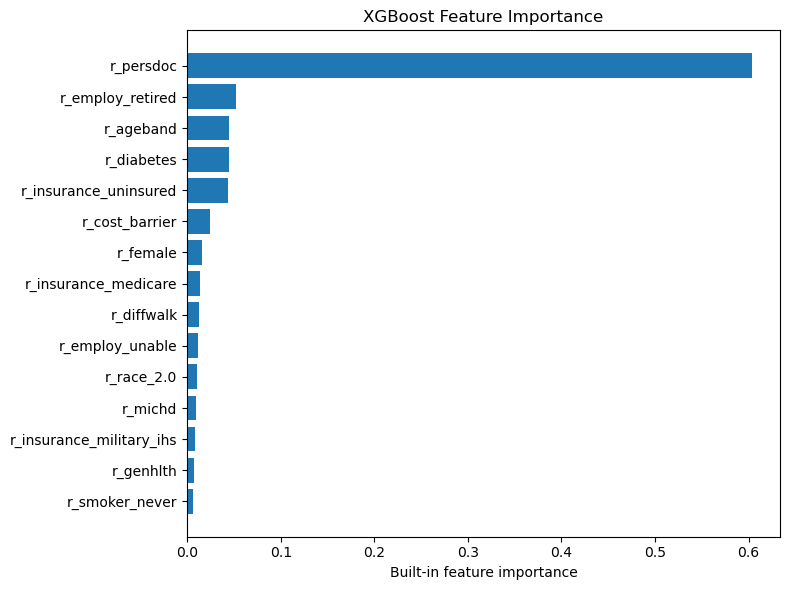

In [18]:
xgb_results = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": xgboost_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_results.to_csv(
    RESULTS / "xgboost_feature_importance.csv",
    index=False
)

print("Top XGBoost Predictors")
display(xgb_results.head(15).round(4))

xgb_top = xgb_results.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(xgb_top["Feature"], xgb_top["Importance"])
plt.xlabel("Built-in feature importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig(
    RESULTS / "xgboost_feature_importance.png",
    dpi=200
)
plt.show()


### 4.4 Consistent Predictors Across the Three Selected Models


In [19]:
top_n = 10

lr_top_features = set(lr_results.head(top_n)["Feature"])
rf_top_features = set(rf_results.head(top_n)["Feature"])
xgb_top_features = set(xgb_results.head(top_n)["Feature"])

common_all_three = (
    lr_top_features
    & rf_top_features
    & xgb_top_features
)

common_any_two = (
    (lr_top_features & rf_top_features)
    | (lr_top_features & xgb_top_features)
    | (rf_top_features & xgb_top_features)
)

print("Features appearing in the Top 10 of ALL THREE models:")
print(sorted(common_all_three))

print("\nFeatures appearing in the Top 10 of AT LEAST TWO models:")
print(sorted(common_any_two))


Features appearing in the Top 10 of ALL THREE models:
['r_cost_barrier', 'r_diabetes', 'r_employ_retired', 'r_insurance_uninsured', 'r_persdoc']

Features appearing in the Top 10 of AT LEAST TWO models:
['r_ageband', 'r_cost_barrier', 'r_diabetes', 'r_diffwalk', 'r_employ_retired', 'r_employ_unable', 'r_female', 'r_insurance_medicare', 'r_insurance_uninsured', 'r_persdoc']


In [20]:
key_findings = pd.DataFrame({
    "Logistic Regression": lr_results.head(10)["Feature"].reset_index(drop=True),
    "Random Forest": rf_results.head(10)["Feature"].reset_index(drop=True),
    "XGBoost": xgb_results.head(10)["Feature"].reset_index(drop=True)
})

key_findings.index = range(1, len(key_findings) + 1)

print("Top Predictors Across the Three Selected Models")
display(key_findings)


Top Predictors Across the Three Selected Models


,Logistic Regression,Random Forest,XGBoost
1,r_persdoc,r_persdoc,r_persdoc
2,r_diabetes,r_ageband,r_employ_retired
3,r_insurance_uninsured,r_employ_retired,r_ageband
4,r_cost_barrier,r_diabetes,r_diabetes
5,r_insurance_military_ihs,r_insurance_uninsured,r_insurance_uninsured
6,r_race_2.0,r_insurance_medicare,r_cost_barrier
7,r_employ_unable,r_cost_barrier,r_female
8,r_employ_retired,r_female,r_insurance_medicare
9,r_smoker_former,r_diffwalk,r_diffwalk
10,r_michd,r_genhlth,r_employ_unable


## 5. Additional Exploratory Analysis — Decision Tree

The Decision Tree is retained for exploratory purposes. It is not included in the primary three-model results.


In [21]:
exploratory_dt_results = pd.DataFrame([dt_metrics])

print("Exploratory Decision Tree Performance")
display(
    exploratory_dt_results[
        [
            "Model", "Accuracy", "Sensitivity", "Specificity",
            "Precision", "F1", "AUROC", "AUPRC", "Brier"
        ]
    ].round(3)
)

dt_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": decision_tree.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Decision Tree Predictors")
display(dt_importance.head(15).round(4))


Exploratory Decision Tree Performance


,Model,Accuracy,Sensitivity,Specificity,Precision,F1,AUROC,AUPRC,Brier
0,Decision Tree,0.782,0.639,0.814,0.432,0.516,0.798,0.491,0.172



Top Decision Tree Predictors


,Feature,Importance
25,r_persdoc,0.6668
36,r_ageband,0.2236
29,r_diabetes,0.0513
6,r_insurance_uninsured,0.0177
26,r_cost_barrier,0.0147
35,r_female,0.0144
21,r_employ_retired,0.0058
2,r_insurance_military_ihs,0.0018
7,r_smoker_former,0.0009
27,r_genhlth,0.0008


## 6. Key Findings

Logistic Regression was used as the baseline model, with Random Forest and XGBoost used as additional machine-learning approaches. All three selected models demonstrated similar discrimination, with AUROC values around 0.81. XGBoost achieved the highest AUROC (0.816), AUPRC (0.561) and sensitivity (0.685), while Random Forest achieved the lowest Brier score (0.165).

Model interpretation identified several predictors that were consistently important across the three selected approaches. Personal doctor status (`r_persdoc`), diabetes (`r_diabetes`), uninsured status (`r_insurance_uninsured`), cost-related barriers (`r_cost_barrier`) and retired employment status (`r_employ_retired`) appeared among the top 10 predictors in all three models.

Logistic Regression additionally provided the direction of association. Being uninsured was associated with higher odds of a preventive care gap (OR = 1.847), while reporting a cost barrier was also associated with higher odds (OR = 1.760). Personal doctor status showed the strongest association (OR = 0.143).

Overall, the consistency across Logistic Regression, Random Forest and XGBoost indicates that healthcare access and continuity-of-care factors are important predictors of preventive care gaps.

> **Interpretation caution:** confirm the exact coding/reference category of each recoded predictor before translating coefficients or odds ratios into substantive statements such as “having” versus “not having” a personal doctor.
